In [3]:
import os
import torch
import cv2
import yaml
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from ultralytics import YOLO

# Pastikan RTX 3050 terbaca
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware aktif: {device.type.upper()}")
if device.type == 'cuda':
    print(f"Nama GPU: {torch.cuda.get_device_name(0)}")

Hardware aktif: CUDA
Nama GPU: NVIDIA GeForce RTX 3050 Laptop GPU


pembuatan kelas dataset

In [4]:
yaml_path = "../data/data.yaml"

with open(yaml_path, 'r') as file:
    data_yaml = yaml.safe_load(file)

data_yaml['train'] = 'train/images'
data_yaml['val'] = 'valid/images'
data_yaml['test'] = 'test/images'

with open(yaml_path, 'w') as file:
    yaml.dump(data_yaml, file, default_flow_style=False)

print("File data.yaml berhasil diperbarui secara otomatis!")
print(f"Path Train sekarang: {data_yaml['train']}")

File data.yaml berhasil diperbarui secara otomatis!
Path Train sekarang: train/images


Inisialisasi Pipeline & Transfer ke VRAM GPU

=== HASIL PREPROCESSING ===
File: 0_jpg.rf.0968e57945dea5498b11b1c41aff0a65.jpg
Bentuk Matrix Tensor: [3, 224, 224] -> [Channel, Height, Width]


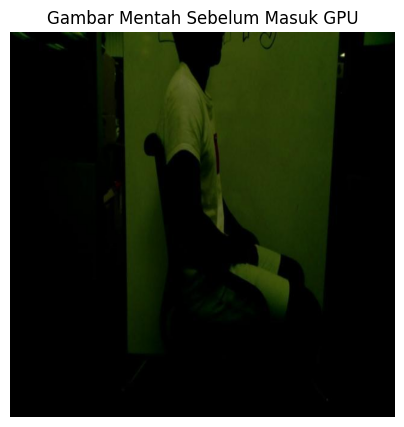

In [5]:
train_img_dir = "../data/train/images"
sample_img_name = os.listdir(train_img_dir)[0]
sample_path = os.path.join(train_img_dir, sample_img_name)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img = Image.open(sample_path).convert("RGB")
img_tensor = transform(img) # <--- Nah, img_tensor baru dibuat di sini!

print("=== HASIL PREPROCESSING ===")
print(f"File: {sample_img_name}")
print(f"Bentuk Matrix Tensor: {list(img_tensor.shape)} -> [Channel, Height, Width]")

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Gambar Mentah Sebelum Masuk GPU")
plt.axis('off')
plt.show()

Visualisasi Batch

In [6]:
print("=== MEMULAI PROSES TRAINING YOLOv8 (MVP) ===")

# 1. Load model dasar YOLOv8 versi Nano (Object Detection)
model = YOLO('yolov8n.pt') 

# 2. Gas Training 25 Putaran pakai RTX 3050
results = model.train(
    data=yaml_path,
    epochs=25,       
    imgsz=640,       
    batch=16,        
    device=0,        
    project='../runs/detect', 
    name='posture_mvp_final',
    plots=True       
)

print("\n=== TRAINING SELESAI ===")
print("Grafik analitik dan model tersimpan di: runs/detect/posture_mvp_final/")

=== MEMULAI PROSES TRAINING YOLOv8 (MVP) ===
Ultralytics 8.4.48  Python-3.10.6 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=posture_mvp_final, nbs=64, nms=False, opset=None, 